# PathFinder on real FMRI data

Here we try to relate task and resting state data




In [1]:
from pathfinder import utils, decomp
# -- here while dev in progress
import importlib
importlib.reload(utils)
importlib.reload(decomp)
# ---

<module 'pathfinder.decomp' from '/opt/miniconda3/envs/py38/lib/python3.8/site-packages/pathfinder/decomp.py'>

In [2]:
%%bash
# Parcellate Task and Rest
dlabel=/Users/saad/data/GlasserParcellation.dlabel.nii

task_subj=/Users/saad/data/MSMAll_All_task_maps_100307.dtseries.nii
task_group=/Users/saad/data/HCP_S1200_997_tfMRI_ALLTASKS_level2_cohensd_hp200_s4_MSMAll.dscalar.nii

wb_command -cifti-parcellate $task_group $dlabel COLUMN task_g.pscalar.nii
wb_command -cifti-parcellate $task_subj $dlabel COLUMN task_s.ptseries.nii

rest=/Users/saad/data/groupPCA_3T_HCP1200_MSMAll_d4500.dtseries.nii
cp $rest rest.dtseries.nii

wb_command -cifti-parcellate $rest $dlabel COLUMN rest.ptseries.nii



In [3]:
# Now load the data and turn into matrices

import nibabel as nib
rest   = nib.load('rest.ptseries.nii')
task_s = nib.load('task_s.ptseries.nii')
task_g = nib.load('task_g.pscalar.nii')


# # Also have GeneExpr and XtractBP
# gene   = nib.load('/Users/saad/data/GeneExpression/GeneExp_brain.pscalar.nii')
# xtract = nib.load('/Users/saad/data/GeneExpression/BP.pscalar.nii')


In [4]:
Domains    = ['right', 'left']
Modalities = ['rest', 'task_g', 'task_s']
Missing    = []


# Only task_g
RealDataSets_Complete = {
'right'  : {'rest'  : rest.get_fdata()[:100,:180].T,
           'task_g' : task_g.get_fdata()[:,:180].T,
           },    
'left'  : {'rest'   : rest.get_fdata()[:100,180:].T,
           'task_g' : task_g.get_fdata()[:,180:].T,
          },
}

RealDataSets = {
'right'  : {'rest'  : rest.get_fdata()[:100,:180].T,
           'task_g' : task_g.get_fdata()[:,:180].T,
           },
'left'  : {'rest'   : rest.get_fdata()[:100,180:].T,
           'task_g' : None,
          }
}

In [13]:
# Fit the data
from pathfinder import decomp, utils

from sklearn.linear_model import Ridge
algo = decomp.JointOuterDecomp(n_components=5, n_iter=30, dropout=-1,
                               method=Ridge, method_kwargs={'alpha':1e2}, do_ica='both')

algo.fit(RealDataSets)


100%|████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 389.91it/s]


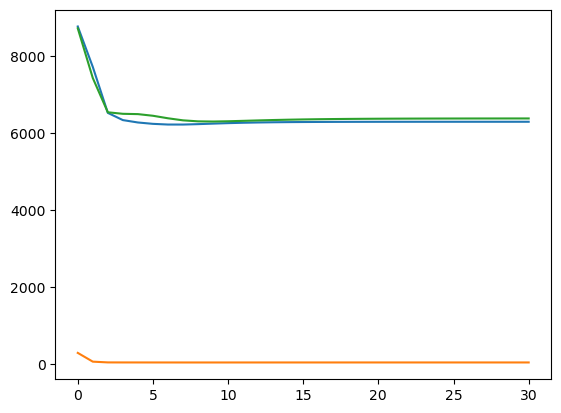

In [14]:
# Plot error
import matplotlib.pyplot as plt
_ = plt.plot(algo._loss)


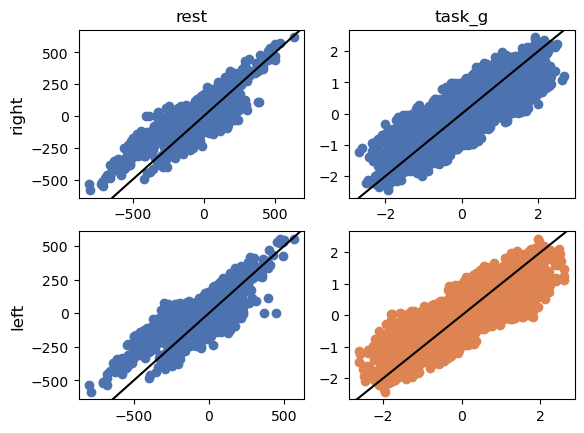

In [15]:
# Plot data and fit
_ = utils.plot_data_fit(RealDataSets, algo._A, algo._S, RealDataSets_Complete)

A, S = algo._A, algo._S

In [16]:
# Visualise components with nilearn
# Need to figure out how to do that on pscalar files
[s.shape for s in algo._S]

[(100, 5), (86, 5)]

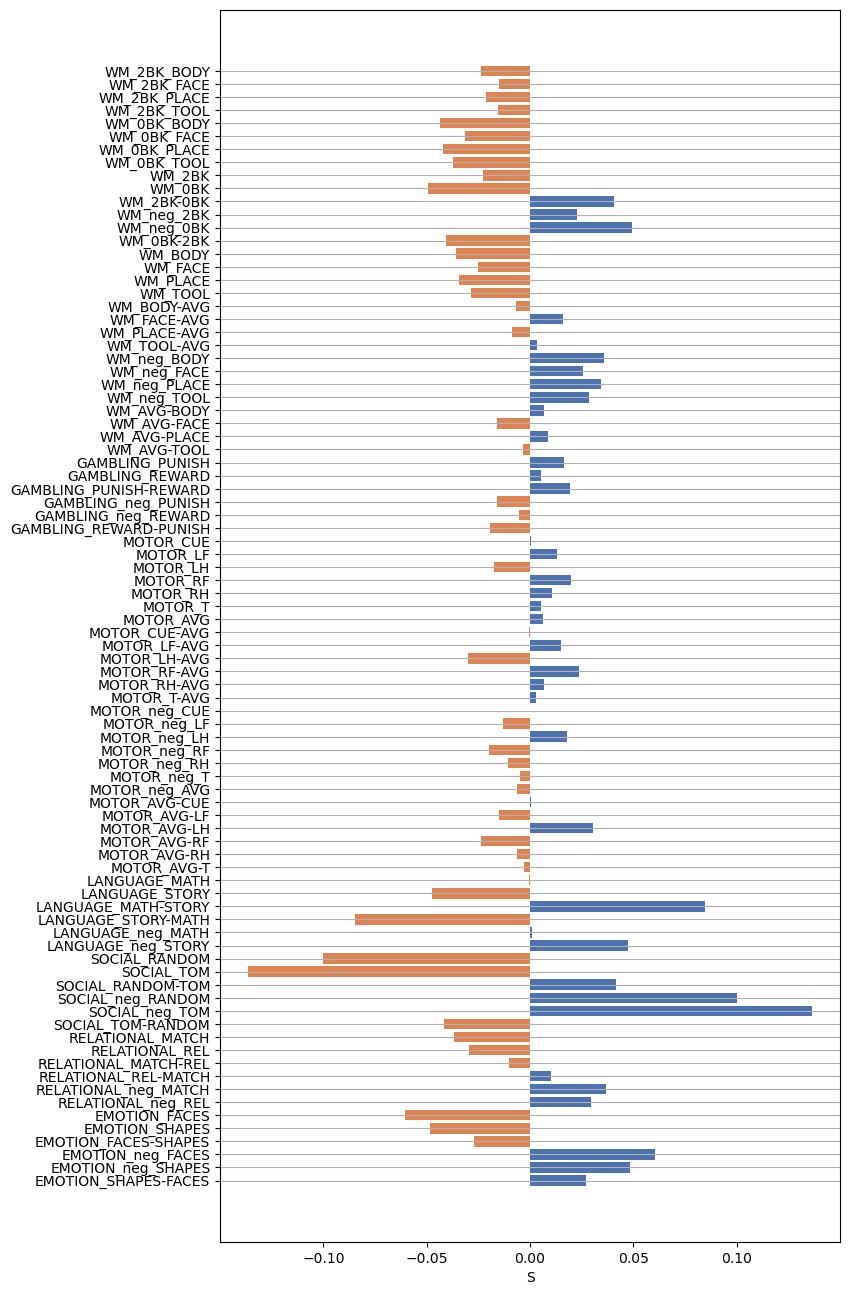

In [17]:
# Plot S for the task data
import matplotlib.pyplot as plt
import numpy as np
comp = 0
data = S[1][:,comp]
name = [n[6:] for n in task_g.header.get_axis(0).name]


fig, ax = plt.subplots(figsize=(8,16))

y_pos = np.arange(len(name))

ax.barh(y_pos[data>0], data[data>0], align='center', color='#4c72b0ff')
ax.barh(y_pos[data<0], data[data<0], align='center', color='#dd8452ff')
ax.set_yticks(y_pos, labels=name)
ax.invert_yaxis()  
ax.set_xlabel('S')
ax.grid(which='major',axis='y')
plt.show()
